# Reward Model Debug

In [21]:
from pathlib import Path
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, SubprocVecEnv

import sumo_rl_ego as sre
from human_feedback_rl.common.trajectory_generators import TrajectoryGeneratorFromAgent

from loadings import load_reward_ensemble
from plot_functions import plot_scatter, plot_scatter_all_models, plot_reward_curves

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

In [22]:
RUN_DIR = Path("/work/fis1/sumo-human-feedback-rl/outputs/ppo_chri binary_bernulli seg1 tot_queries=1010000 seed=0 v02")

import sumo_gym_ego.core.simulation as _sim_mod
import traci as _traci_mod
_sim_mod.load_traci = lambda use_gui: _traci_mod

try:
    env.close()
except Exception:
    pass

env = sre.make_vec_env(
    "HighwayEgo-v0",
    n_envs=4,
    base_seed=0,
    ego="continuous",
    reward="fast"
)

checkpoint_dirs = sorted(RUN_DIR.glob("checkpoint_*"))

reward_models_list = []
agents_list = []

for ckpt_dir in checkpoint_dirs:
    reward_model = load_reward_ensemble(
        ckpt_dir / "reward_model.pt",
        env.observation_space,
        env.action_space,
    )
    agents = PPO.load(
        ckpt_dir / "agent.zip", 
        env=env, 
        device="cpu"
    )
    reward_models_list.append(reward_model)
    agents_list.append(agents)

print(f"Loaded {len(agents_list)} checkpoints: {[d.name for d in checkpoint_dirs]}")


Environment closed.

Environment closed.
Environment closed.

Environment closed.



Loaded 3 checkpoints: ['checkpoint_0010', 'checkpoint_0020', 'checkpoint_0030']


In [23]:
ID = -1
N_STEPS = 10000

trajectory_generator = TrajectoryGeneratorFromAgent(
    agent=agents_list[ID],
    reward_model=reward_models_list[ID],
    venv=env,
)

trajectories = trajectory_generator.sample(N_STEPS)

In [24]:

# next_status: 7-dim one-hot [arrived, collided, off_road, timeout, running, teleported, removed_unknown]
STATUS_ARRIVED  = 0
STATUS_COLLIDED = 1
STATUS_OFFROAD  = 2
STATUS_TIMEOUT  = 3

terminal_statuses = [np.argmax(traj[-1].next_status) for traj in trajectories]

n_episodes = len(trajectories)
n_arrived  = sum(s == STATUS_ARRIVED  for s in terminal_statuses)
n_collided = sum(s == STATUS_COLLIDED for s in terminal_statuses)
n_offroad  = sum(s == STATUS_OFFROAD  for s in terminal_statuses)
n_timeout  = sum(s == STATUS_TIMEOUT  for s in terminal_statuses)

print(f"Episodi totali:        {n_episodes}")
print()
print(f"Terminazioni:")
print(f"  Arrived:  {n_arrived:3d}  ({100 * n_arrived  / n_episodes:.1f}%)")
print(f"  Collided: {n_collided:3d}  ({100 * n_collided / n_episodes:.1f}%)")
print(f"  Off-road: {n_offroad:3d}  ({100 * n_offroad  / n_episodes:.1f}%)")
print(f"  Timeout:  {n_timeout:3d}  ({100 * n_timeout  / n_episodes:.1f}%)")

Episodi totali:        62

Terminazioni:
  Arrived:   50  (80.6%)
  Collided:  10  (16.1%)
  Off-road:   2  (3.2%)
  Timeout:    0  (0.0%)


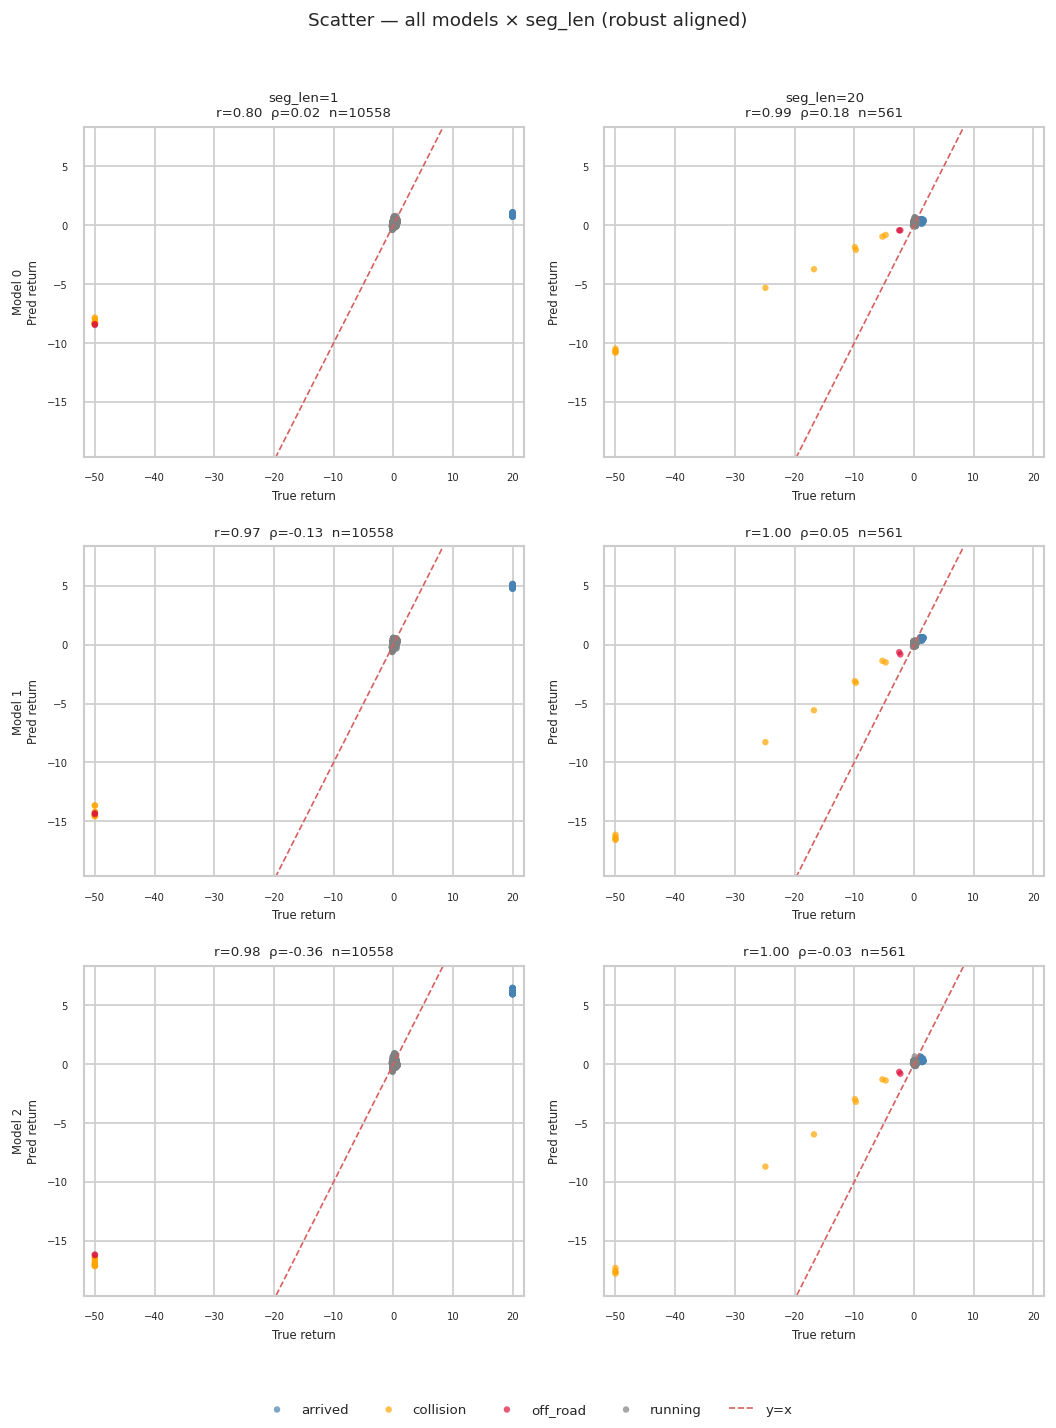

In [27]:
seg_lens = [1, 20]
plot_scatter_all_models(trajectories, reward_models_list, seg_lens, normalize=True, robust=True)

In [26]:
import pickle

SAVE_PATH = "/home/ricca/projects/sumo-human-feedback-rl/data_for_training/debug_dataset_seg1.pkl"

with open(SAVE_PATH, "rb") as f:
     data = pickle.load(f)

debug_segments = sum((data[s] for s in range(len(data))), [])

plot_scatter_all_models(debug_segments, reward_models_list, seg_lens=[None], normalize=False, robust=False)

FileNotFoundError: [Errno 2] No such file or directory: '/home/ricca/projects/sumo-human-feedback-rl/data_for_training/debug_dataset_seg1.pkl'

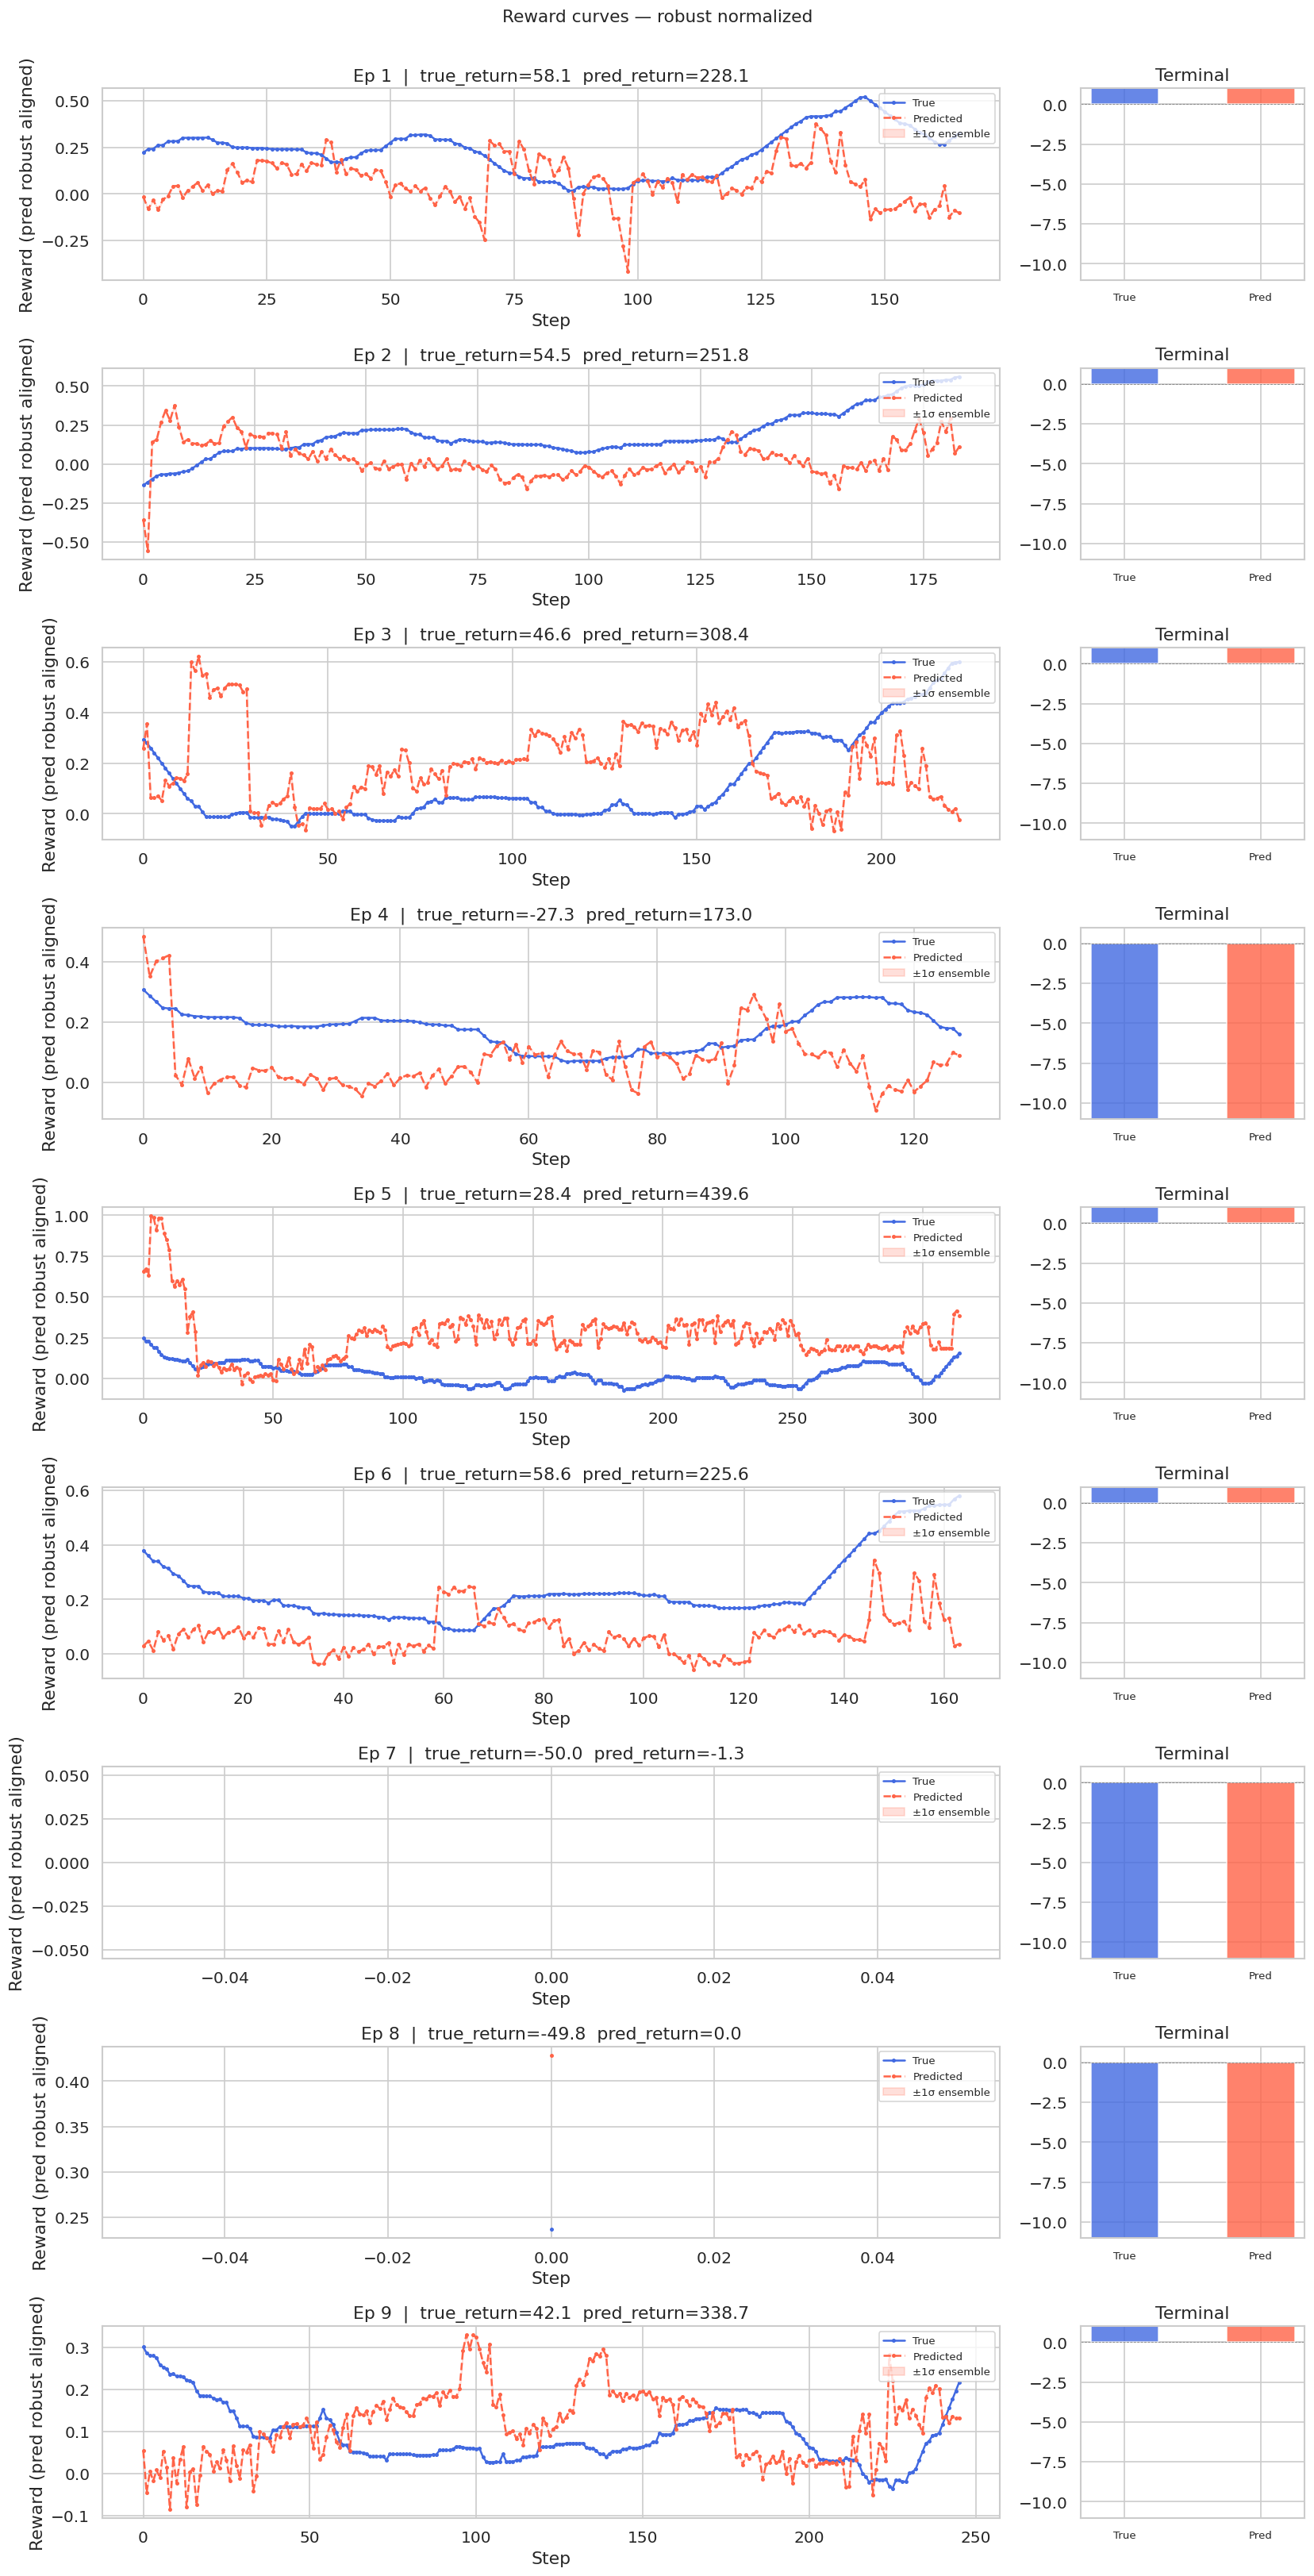

In [28]:
ID = -1
N_TRAJ = 10

plot_reward_curves(trajectories[0:N_TRAJ-1], reward_models_list[ID], normalize=True, robust=True)